In [ ]:
import torch
import torch.nn  as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim



In [ ]:
num_epochs = 100
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),
                         (0.5,0.5,0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),
                         (0.5,0.5,0.5))
])
device = torch.device('cuda' if torch.cuda.is_available else 'cpu')


In [ ]:
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True, download=True,
    transform=train_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True, transform=test_transform
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [ ]:
class EarlyStopping:

    def __init__(
        self,
        patience=10,
        min_delta=1e-3,
        path="best_model.pt",
        verbose=True
    ):

        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.verbose = verbose
        self.best_loss = float("inf")
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss, model):

        improved = val_loss < self.best_loss - self.min_delta

        if improved:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
            if self.verbose:
                print(f"Validation improved. Model saved.")

        else:
            self.counter += 1
            if self.verbose:
                print(
                    f"No improvement for "
                    f"{self.counter}/{self.patience} epochs"
                )

            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print("Early stopping triggered.")
        return self.early_stop

In [ ]:
class SimpleCNN(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [ ]:
import torch
ealy_stopper = EarlyStopping(patience=10)
from torch.optim.lr_scheduler import CosineAnnealingLR as cosine
model = SimpleCNN().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = cosine(optimizer, T_max=50, eta_min=1e-5)
criterion = nn.CrossEntropyLoss()

In [ ]:
from tqdm import tqdm

train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    for (images, labels) in tqdm(train_loader, desc='Training Lopp'):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()

        train_loss = running_loss/ len(train_loader)
        train_losses.append(train_loss)
    print(f"Epoch: {epoch+1}/{num_epochs}, Training Loss: {train_loss:.4f} |"
           f"Training Accuracy: {100 * correct / len(train_loader.dataset):.2f}%")

    model.eval()
    val_loss = 0.0
    correct_val = 0
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc= 'Evaluating loop' ):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()


    val_loss = val_loss/ len(test_loader)
    val_losses.append(val_loss)
    print(f"Epoch: {epoch+1}/{num_epochs}, Validation Loss: {val_loss:.4f} |"
          f"Validation Accuracy: {100 * correct_val / len(test_loader.dataset):.2f}%")

    scheduler.step()
    if ealy_stopper(val_loss, model):
        break

Training Lopp: 100%|██████████| 1563/1563 [00:26<00:00, 58.38it/s]


Epoch: 1/100, Training Loss: 1.3511 |Training Accuracy: 50.59%


Evaluating loop: 100%|██████████| 313/313 [00:03<00:00, 94.53it/s]


Epoch: 1/100, Validation Loss: 1.0772 |Validation Accuracy: 61.59%
Validation improved. Model saved.


Training Lopp: 100%|██████████| 1563/1563 [00:27<00:00, 57.48it/s]


...

Epoch: 30/100, Validation Loss: 0.4521 |Validation Accuracy: 89.30%
No improvement for 9/10 epochs


Training Lopp: 100%|██████████| 1563/1563 [00:28<00:00, 54.38it/s]


Epoch: 31/100, Training Loss: 0.0177 |Training Accuracy: 99.51%


Evaluating loop: 100%|██████████| 313/313 [00:04<00:00, 77.21it/s]

Epoch: 31/100, Validation Loss: 0.4638 |Validation Accuracy: 89.25%
No improvement for 10/10 epochs
Early stopping triggered.


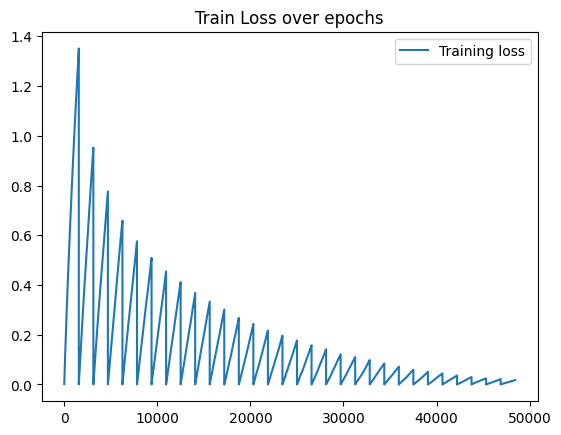

In [ ]:
plt.plot(train_losses, label='Training loss')
plt.legend()
plt.title("Train Loss over epochs")
plt.show()

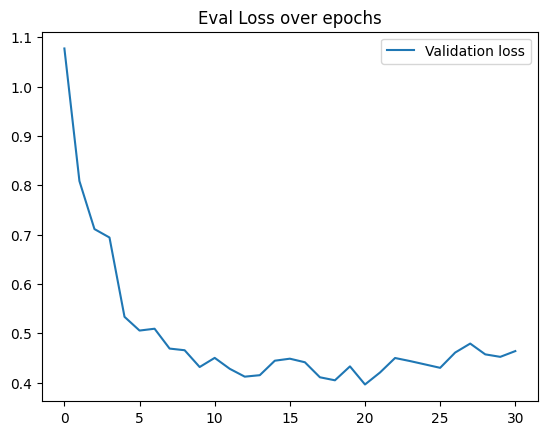

In [ ]:
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.title("Eval Loss over epochs")
plt.show()

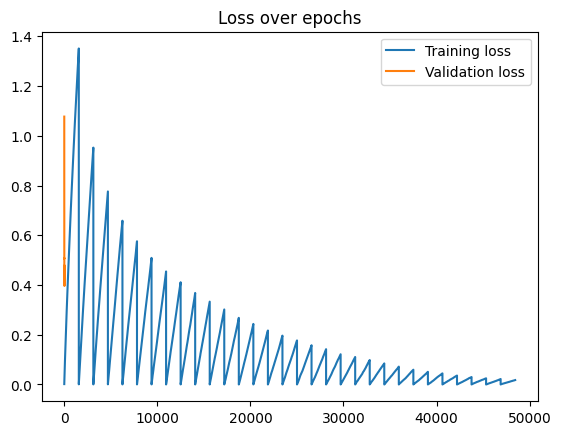

In [ ]:
plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()